# Diabetes Prediction from Clinical Measurements

**CBIO313 - Data Mining & Machine Learning · Course Project**

Instructor: Dr. Muhammad Elsayeh

---

## 1. Problem definition and objectives

Type 2 diabetes develops silently. By the time symptoms send someone to a clinic, damage to the
kidneys, retina and peripheral nerves is often already underway. Screening programmes exist for
exactly this reason, but a full diagnostic workup is expensive and cannot be offered to an entire
population. A cheap triage step that flags who most needs that workup is therefore genuinely useful.

**Problem.** Given eight routine clinical and demographic measurements, predict whether a patient
has diabetes. This is a **binary supervised classification** problem.

**Objectives**

1. Clean a dataset in which missing values were silently recorded as zeros.
2. Explore how each measurement relates to diabetes status.
3. Train and compare **five** classification algorithms taught in this course.
4. Evaluate them with metrics appropriate to an imbalanced medical screening task - not accuracy alone.
5. Tune the winning model and choose a decision threshold that suits screening.
6. Explain *why* the model predicts what it predicts, so a clinician could interrogate it.

**The metric that matters.** In screening, the two errors are not equal. A false positive sends a
healthy patient for a confirmatory blood test - inconvenient and a little costly. A false negative
sends an undiagnosed diabetic home reassured. We therefore optimise for **recall on the positive
class** (the share of true diabetics we catch), while watching precision so the model does not
degenerate into flagging everybody.

## 2. Dataset description

**Source.** National Institute of Diabetes and Digestive and Kidney Diseases, distributed via the
UCI Machine Learning Repository as the *Pima Indians Diabetes Database*. The copy used here is
checked into `data/diabetes.csv` so this notebook runs offline.

**Population.** 768 women of Pima Indian heritage, all aged 21 or older, living near Phoenix,
Arizona. This narrow population is important and is revisited in the limitations.

| Column | Meaning | Unit |
|---|---|---|
| `Pregnancies` | Number of times pregnant | count |
| `Glucose` | Plasma glucose, 2 h into an oral glucose tolerance test | mg/dL |
| `BloodPressure` | Diastolic blood pressure | mm Hg |
| `SkinThickness` | Triceps skin-fold thickness | mm |
| `Insulin` | 2-hour serum insulin | mu U/mL |
| `BMI` | Body mass index | kg/m² |
| `DiabetesPedigreeFunction` | Family-history-weighted diabetes likelihood score | - |
| `Age` | Age | years |
| `Outcome` | **Target**: 1 = diabetes, 0 = no diabetes | binary |

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, 'src')
from data_prep import FEATURES, TARGET, ZERO_AS_MISSING, clean, load_raw, missing_report

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120)
RANDOM_STATE = 42

raw = load_raw()
print('shape:', raw.shape)
raw.head()

shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## 3. Data preprocessing

### 3.1 The zeros are not zeros

Read the `min` row of the table above. `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and
`BMI` all bottom out at **0**. None of those is biologically possible in a living patient - a BMI of
zero, or a blood pressure of zero, would mean the person is not alive. These zeros are **missing
measurements that were never encoded as missing**.

A model trained on the raw file would treat "insulin = 0" as a genuine, extremely low insulin
reading, which is exactly the opposite of the truth. Quantifying and fixing this is the single most
important preprocessing step in this dataset.

(`Pregnancies` is excluded: zero pregnancies is perfectly real. `Age` and
`DiabetesPedigreeFunction` never contain zeros.)

In [4]:
missing_report(raw)

,zeros,percent
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


Almost **half** of the insulin readings and nearly a third of the skin-fold measurements are absent.
That rules out dropping incomplete rows - doing so would discard roughly half the dataset and, worse,
the rows that are missing insulin are unlikely to be a random sample of patients.

### 3.2 Strategy: mark as missing, impute inside the pipeline

We replace the impossible zeros with `NaN`, then impute with the **median** (robust to the heavy
right skew visible in the distributions below).

The critical detail: imputation is placed **inside a scikit-learn `Pipeline`**, not applied to the
whole dataset up front. If we computed the median over all 768 rows and then split, information from
the test patients would leak into the training data and every score below would be optimistically
biased. Inside a pipeline, the median is recomputed from the training portion of each
cross-validation fold.

In [5]:
cleaned = clean(raw)
print('NaNs after marking impossible zeros as missing:')
print(cleaned[ZERO_AS_MISSING].isna().sum())
cleaned.head()

NaNs after marking impossible zeros as missing:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [6]:
from sklearn.model_selection import train_test_split

X, y = cleaned[FEATURES], cleaned[TARGET]

# Stratified so the 65/35 class ratio is preserved in both halves.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f'train: {X_train.shape[0]} patients   test: {X_test.shape[0]} patients')
print(f'positive rate  train {y_train.mean():.3f}   test {y_test.mean():.3f}')

train: 614 patients   test: 154 patients
positive rate  train 0.349   test 0.351


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def make_pipeline(model):
    """Impute -> scale -> classify, as one estimator.

    Scaling matters for KNN, SVM and regularised logistic regression: without it, Insulin
    (values in the hundreds) would dominate every distance calculation over
    DiabetesPedigreeFunction (values below 3).
    """
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', model),
    ])


make_pipeline(None)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('impute', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account

## 4. Exploratory data analysis

### 4.1 Class balance and the extent of the missing data

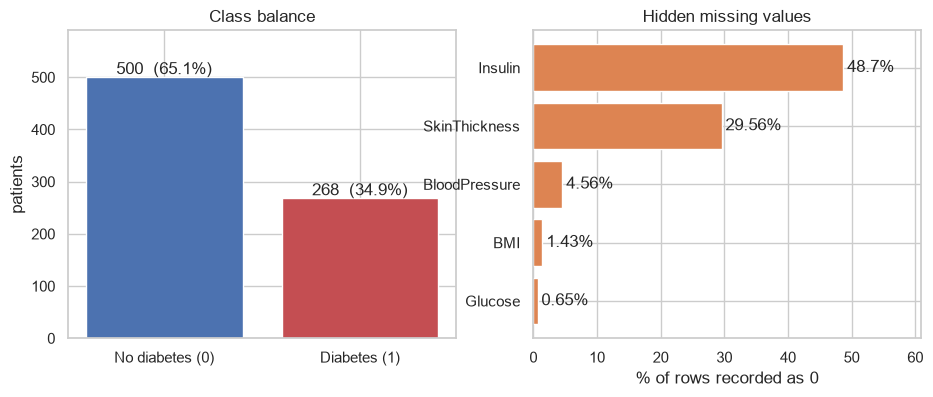

In [8]:
counts = raw[TARGET].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(['No diabetes (0)', 'Diabetes (1)'], counts.values, color=['#4c72b0', '#c44e52'])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 6, f'{v}  ({v / len(raw):.1%})', ha='center')
ax[0].set_ylabel('patients'); ax[0].set_title('Class balance')
ax[0].set_ylim(0, counts.max() * 1.18)

rep = missing_report(raw)
ax[1].barh(rep.index[::-1], rep['percent'][::-1], color='#dd8452')
for i, v in enumerate(rep['percent'][::-1]):
    ax[1].text(v + 0.6, i, f'{v}%', va='center')
ax[1].set_xlabel('% of rows recorded as 0'); ax[1].set_title('Hidden missing values')
ax[1].set_xlim(0, rep['percent'].max() * 1.25)
plt.show()

The classes are imbalanced roughly **65 / 35**. A model that predicts "no diabetes" for every single
patient would score **65% accuracy** while catching zero diabetics. That is the benchmark any result
below must beat, and it is why accuracy alone is a misleading headline for this dataset.

### 4.2 How the measurements differ between the two groups

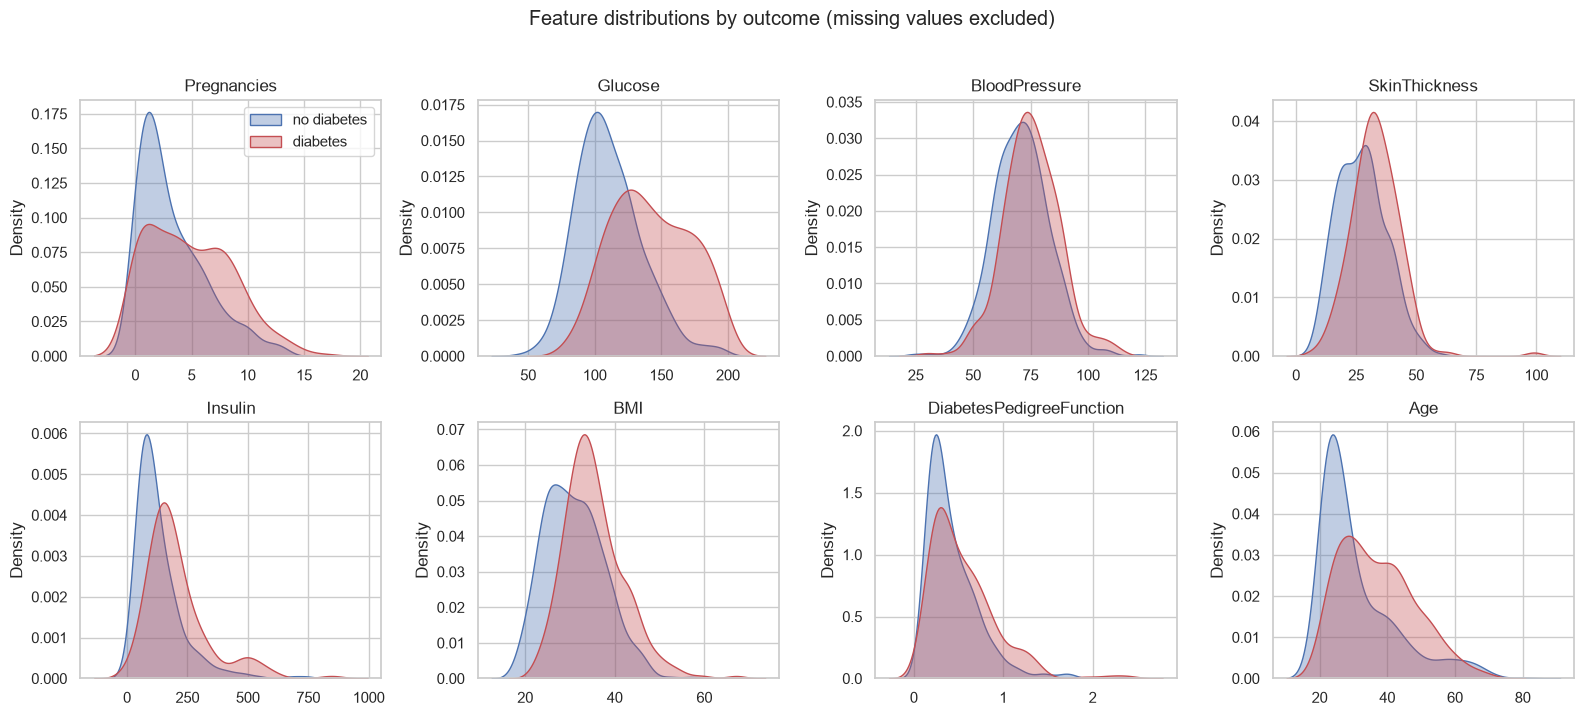

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for axis, col in zip(axes.ravel(), FEATURES):
    for label, colour in ((0, '#4c72b0'), (1, '#c44e52')):
        sns.kdeplot(cleaned.loc[cleaned[TARGET] == label, col].dropna(), ax=axis,
                    fill=True, alpha=0.35, color=colour,
                    label='diabetes' if label else 'no diabetes')
    axis.set_title(col); axis.set_xlabel('')
axes.ravel()[0].legend()
fig.suptitle('Feature distributions by outcome (missing values excluded)', y=1.02)
fig.tight_layout(); plt.show()

`Glucose` separates the two groups far better than anything else - the diabetic curve is shifted
clearly to the right, which is expected given that plasma glucose is part of the diagnostic
definition of diabetes. `BMI` and `Age` show a smaller but visible shift. `BloodPressure` and
`SkinThickness` overlap almost completely, hinting that they will contribute little.

### 4.3 Correlations

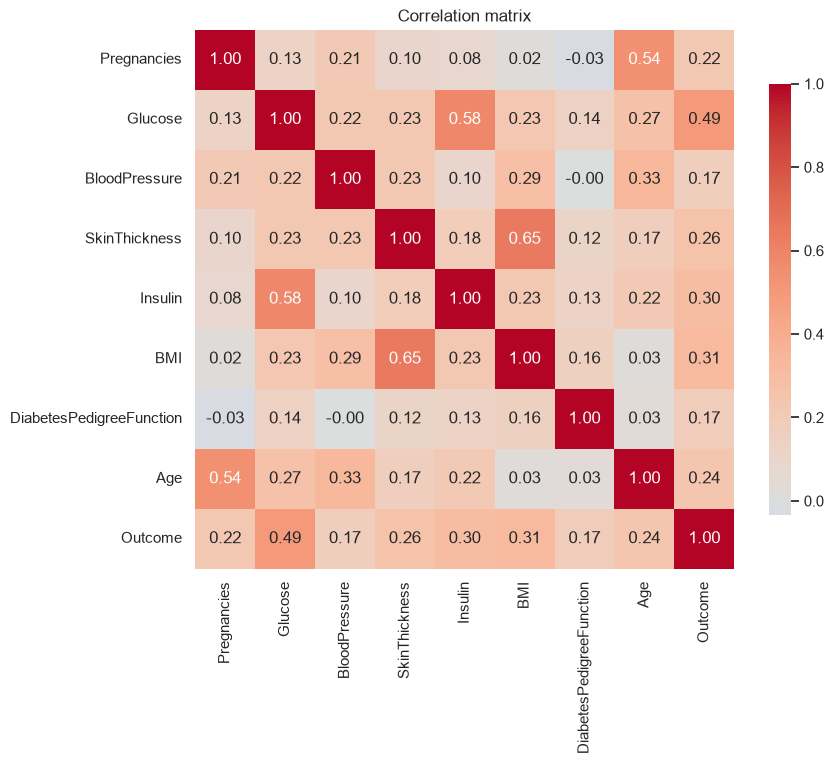

Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171
dtype: float64

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cleaned[FEATURES + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix'); plt.show()

cleaned[FEATURES].corrwith(cleaned[TARGET]).sort_values(ascending=False).round(3)

Two things worth noting:

- **`Glucose` (r ≈ 0.49) is the strongest single correlate of the outcome**, followed by `BMI` and `Age`.
- **`Age` and `Pregnancies` correlate strongly with each other (r ≈ 0.54)**, as do `SkinThickness`
  and `BMI` (r ≈ 0.65). This collinearity means the coefficients of a linear model should not be read
  as independent causal effects, and it is one reason the SHAP analysis in section 8 is more
  trustworthy than raw coefficients.

### 4.4 Spread and outliers

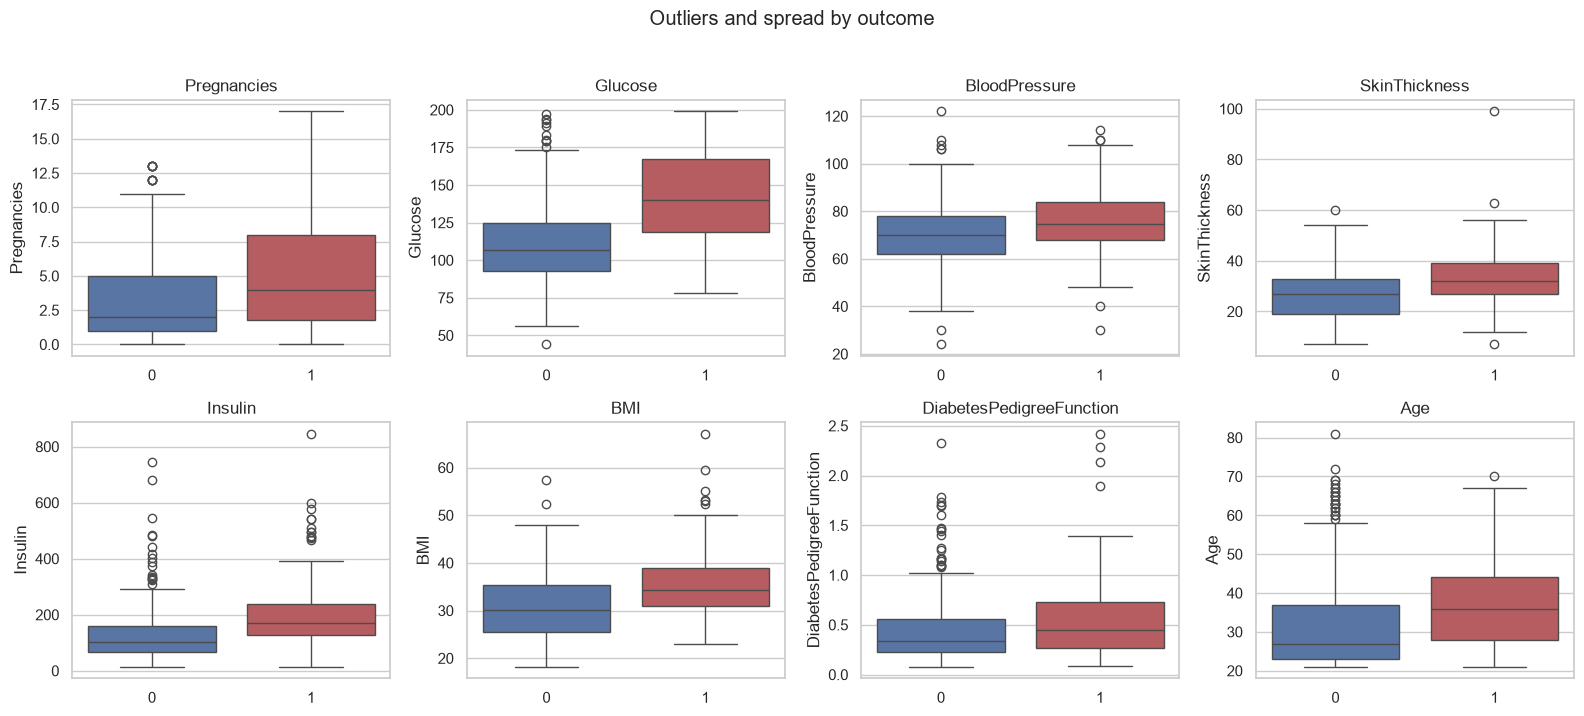

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for axis, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=cleaned, x=TARGET, y=col, ax=axis, hue=TARGET, legend=False,
                palette=['#4c72b0', '#c44e52'])
    axis.set_title(col); axis.set_xlabel('')
fig.suptitle('Outliers and spread by outcome', y=1.02)
fig.tight_layout(); plt.show()

Genuine outliers remain - a `DiabetesPedigreeFunction` above 2, an `Insulin` above 600. These are
clinically plausible extremes rather than data-entry errors, so they are kept. Tree ensembles are
insensitive to them, and `StandardScaler` keeps them from destabilising the distance-based models.

## 5. Machine learning implementation

Five algorithms from the course, each wrapped in the same impute-scale-classify pipeline so the
comparison is fair:

| Algorithm | Why include it |
|---|---|
| **Logistic Regression** | Linear baseline; coefficients are directly interpretable |
| **K-Nearest Neighbours** | Non-parametric, purely local decision rule |
| **Decision Tree** | Interpretable rules; a reference point for the ensemble |
| **Random Forest** | Bagged ensemble; usually the strongest tabular performer |
| **SVM (RBF)** | Maximum-margin classifier with a non-linear kernel |

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=11),
    'Decision Tree'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

fitted = {name: make_pipeline(model).fit(X_train, y_train) for name, model in MODELS.items()}
print('trained:', ', '.join(fitted))

trained: Logistic Regression, K-Nearest Neighbours, Decision Tree, Random Forest, SVM (RBF)


C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 6. Model evaluation and comparison

### 6.1 Cross-validation on the training set

A single train/test split on 768 rows is noisy. Stratified 5-fold cross-validation **on the training
set only** gives a more stable ranking while keeping the test set untouched for the final estimate.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rows = []
for name, model in MODELS.items():
    s = cross_validate(make_pipeline(model), X_train, y_train, cv=cv, scoring=scoring)
    rows.append({'model': name,
                 **{m: round(s[f'test_{m}'].mean(), 4) for m in scoring},
                 'roc_auc_std': round(s['test_roc_auc'].std(), 4)})

cv_table = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
cv_table

C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-

,model,accuracy,precision,recall,f1,roc_auc,roc_auc_std
0,Logistic Regression,0.7882,0.7638,0.5748,0.6545,0.8434,0.0185
1,SVM (RBF),0.7801,0.7415,0.5842,0.6485,0.8333,0.0228
2,K-Nearest Neighbours,0.7525,0.6900,0.5565,0.6109,0.8221,0.0299
3,Random Forest,0.7687,0.6995,0.6028,0.6458,0.8209,0.0209
4,Decision Tree,0.6726,0.5307,0.5795,0.5518,0.6510,0.0148


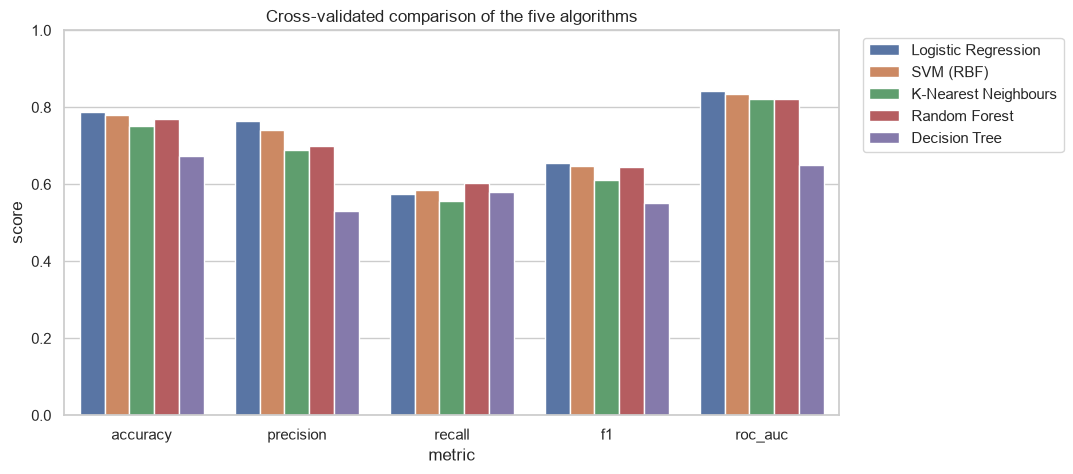

In [14]:
melted = cv_table.melt(id_vars='model',
                       value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                       var_name='metric', value_name='score')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=melted, x='metric', y='score', hue='model', ax=ax)
ax.set_ylim(0, 1); ax.set_title('Cross-validated comparison of the five algorithms')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

**Reading the table.** Logistic Regression and the SVM lead on ROC-AUC; the lone Decision Tree is far
behind, which is the usual story - a single unpruned tree overfits, and the Random Forest that
averages 300 of them recovers most of the lost performance.

Note how much lower **recall** is than accuracy for every model. At the default 0.5 threshold these
classifiers catch only about 55-60% of diabetics. Section 7.2 addresses this directly.

### 6.2 Held-out test set

In [15]:
from sklearn.metrics import (accuracy_score, auc, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)

rows, roc_data = [], {}
for name, pipe in fitted.items():
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name,
                 'accuracy' : round(accuracy_score(y_test, pred), 4),
                 'precision': round(precision_score(y_test, pred), 4),
                 'recall'   : round(recall_score(y_test, pred), 4),
                 'f1'       : round(f1_score(y_test, pred), 4),
                 'roc_auc'  : round(roc_auc_score(y_test, proba), 4)})
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

test_table = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
test_table

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.7403,0.6591,0.5370,0.5918,0.8160
1,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
2,SVM (RBF),0.7403,0.6522,0.5556,0.6000,0.7964
3,K-Nearest Neighbours,0.7338,0.6327,0.5741,0.6019,0.7880
4,Decision Tree,0.6818,0.5532,0.4815,0.5149,0.6357


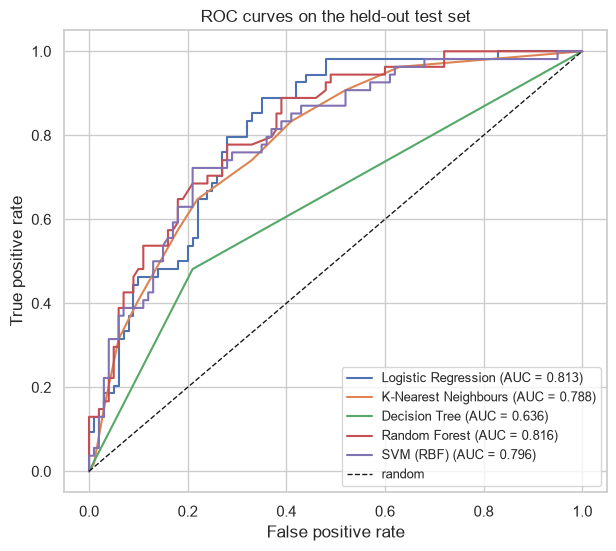

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (fpr, tpr, a) in roc_data.items():
    ax.plot(fpr, tpr, label=f'{name} (AUC = {a:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves on the held-out test set')
ax.legend(loc='lower right', fontsize=9)
plt.show()

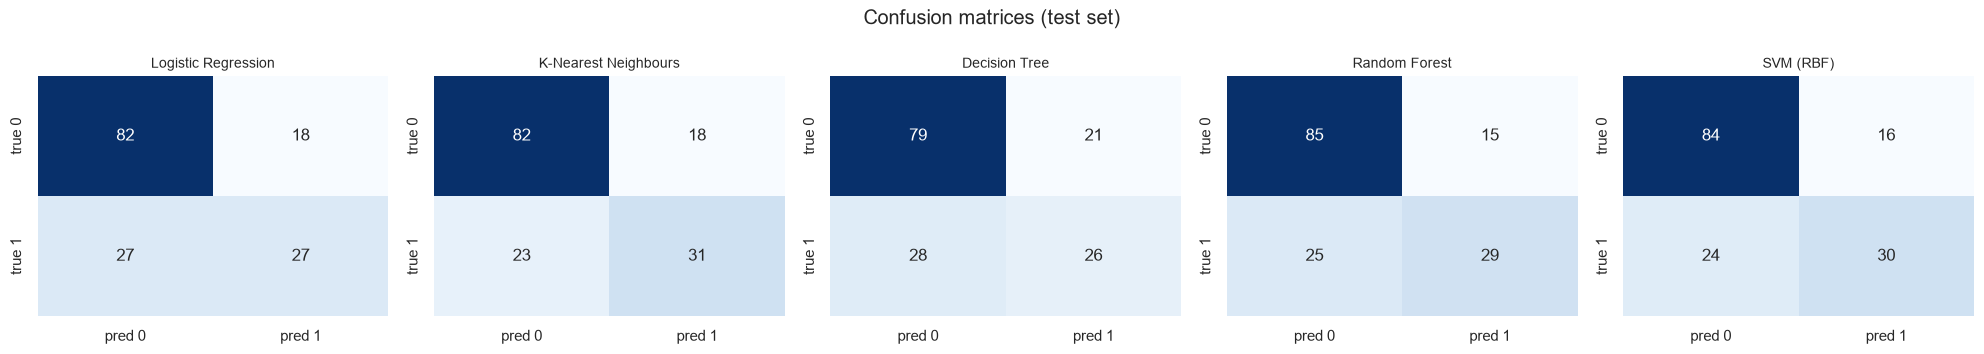

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6))
for axis, (name, pipe) in zip(axes, fitted.items()):
    sns.heatmap(confusion_matrix(y_test, pipe.predict(X_test)), annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=axis,
                xticklabels=['pred 0', 'pred 1'], yticklabels=['true 0', 'true 1'])
    axis.set_title(name, fontsize=10)
fig.suptitle('Confusion matrices (test set)')
fig.tight_layout(); plt.show()

The bottom-left cell of each matrix is the one that matters clinically: those are **diabetics the
model sent home**. Every model leaves 20+ of the 54 test diabetics undetected at the default
threshold.

## 7. Hyperparameter tuning *(bonus)*

### 7.1 Grid search

The grids are scored on **ROC-AUC**, not recall. Optimising a grid directly on recall rewards models
that simply predict "diabetic" more often, which destroys precision - in the limit, predicting
everyone positive scores perfect recall. ROC-AUC ranks models independently of where the decision
threshold sits, and the threshold is then chosen separately in 7.2.

In [18]:
from sklearn.model_selection import GridSearchCV

PARAM_GRIDS = {
    'Logistic Regression': {'model__C': [0.01, 0.1, 1, 10],
                            'model__class_weight': [None, 'balanced']},
    'Random Forest'      : {'model__n_estimators': [200, 400],
                            'model__max_depth': [None, 5, 10],
                            'model__min_samples_leaf': [1, 3, 5],
                            'model__class_weight': [None, 'balanced']},
    'SVM (RBF)'          : {'model__C': [0.1, 1, 10, 100],
                            'model__gamma': ['scale', 0.01, 0.1],
                            'model__class_weight': [None, 'balanced']},
}

tuned, summary = {}, []
for name, grid in PARAM_GRIDS.items():
    search = GridSearchCV(make_pipeline(MODELS[name]), grid, cv=cv,
                          scoring='roc_auc', n_jobs=-1)
    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    summary.append({'model': name,
                    'best_params': {k.replace('model__', ''): v
                                    for k, v in search.best_params_.items()},
                    'cv_roc_auc'  : round(search.best_score_, 4),
                    'test_roc_auc': round(roc_auc_score(y_test, proba), 4)})

pd.DataFrame(summary)

C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,best_params,cv_roc_auc,test_roc_auc
0,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",0.8450,0.8104
1,Random Forest,"{'class_weight': None, 'max_depth': 5, 'min_sa...",0.8388,0.8119
2,SVM (RBF),"{'C': 1, 'class_weight': 'balanced', 'gamma': ...",0.8493,0.8096


In [19]:
# The winner is chosen on CROSS-VALIDATED score from the training set.
# Choosing it by test score would leak the test set into model selection.
best_row  = max(summary, key=lambda r: r['cv_roc_auc'])
best_name = best_row['model']
best_pipe = tuned[best_name]

print(f"Selected model : {best_name}")
print(f"Best parameters: {best_row['best_params']}")
print(f"CV ROC-AUC     : {best_row['cv_roc_auc']:.4f}")
print(f"Test ROC-AUC   : {best_row['test_roc_auc']:.4f}")

Selected model : SVM (RBF)
Best parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01}
CV ROC-AUC     : 0.8493
Test ROC-AUC   : 0.8096


### 7.2 Choosing the decision threshold

`predict()` labels a patient diabetic when the predicted probability exceeds **0.5**. That cut-off
maximises accuracy, which - as established in section 4.1 - is the wrong target here.

We instead pick the threshold that reaches at least **80% recall**, and we pick it from
**out-of-fold predictions on the training set**, so the test set plays no part in the choice.

In [20]:
from sklearn.model_selection import cross_val_predict

oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

grid_t   = np.linspace(0.05, 0.95, 181)
feasible = [(t, recall_score(y_train, (oof >= t).astype(int))) for t in grid_t]
ok        = [t for t, r in feasible if r >= 0.80]
threshold = float(max(ok)) if ok else 0.5

print(f'Chosen threshold (out-of-fold recall >= 80%): {threshold:.3f}')

proba_test   = best_pipe.predict_proba(X_test)[:, 1]
pred_default = (proba_test >= 0.5).astype(int)
pred_tuned   = (proba_test >= threshold).astype(int)


def scores(pred):
    return {'accuracy' : round(accuracy_score(y_test, pred), 4),
            'precision': round(precision_score(y_test, pred, zero_division=0), 4),
            'recall'   : round(recall_score(y_test, pred), 4),
            'f1'       : round(f1_score(y_test, pred), 4)}


pd.DataFrame([{'threshold': 0.50, **scores(pred_default)},
              {'threshold': round(threshold, 3), **scores(pred_tuned)}])

C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Chosen threshold (out-of-fold recall >= 80%): 0.285


,threshold,accuracy,precision,recall,f1
0,0.500,0.7078,0.6000,0.5000,0.5455
1,0.285,0.7208,0.5714,0.8148,0.6718


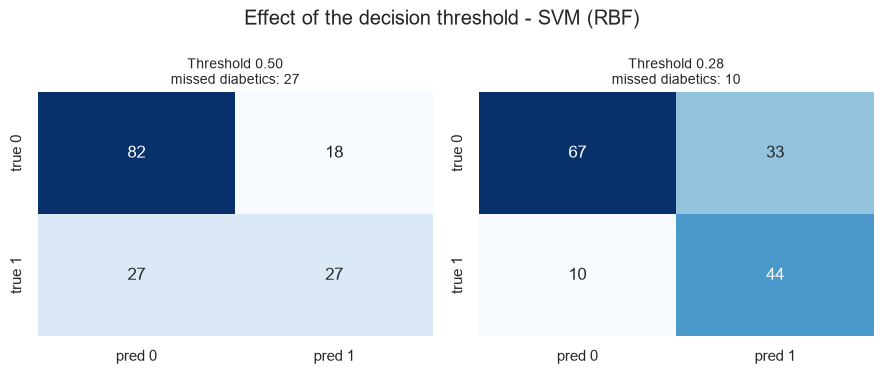

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for axis, (title, pred) in zip(axes, ((f'Threshold 0.50', pred_default),
                                      (f'Threshold {threshold:.2f}', pred_tuned))):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis,
                xticklabels=['pred 0', 'pred 1'], yticklabels=['true 0', 'true 1'])
    axis.set_title(f"{title}\nmissed diabetics: {cm[1, 0]}", fontsize=10)
fig.suptitle(f'Effect of the decision threshold - {best_name}')
fig.tight_layout(); plt.show()

## 8. Explainability *(bonus)*

A model a clinician cannot interrogate will not be used. Two complementary views:

- **Permutation importance** - shuffle one feature and measure how far ROC-AUC falls. Model-agnostic
  and measured on held-out data.
- **SHAP** - attributes each individual prediction to its features, so it explains not just the model
  overall but any single patient.

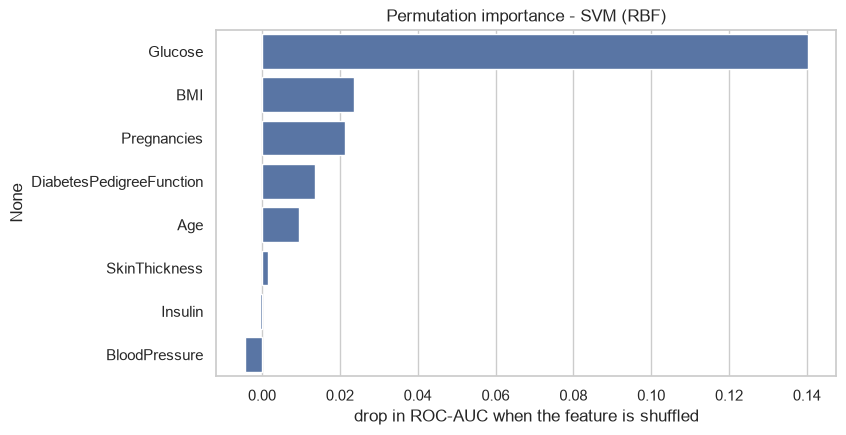

Glucose                     0.1403
BMI                         0.0237
Pregnancies                 0.0214
DiabetesPedigreeFunction    0.0135
Age                         0.0095
SkinThickness               0.0016
Insulin                    -0.0005
BloodPressure              -0.0045
dtype: float64

In [22]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=20,
                              random_state=RANDOM_STATE, scoring='roc_auc')
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color='#4c72b0')
ax.set_xlabel('drop in ROC-AUC when the feature is shuffled')
ax.set_title(f'Permutation importance - {best_name}')
plt.show()

imp.round(4)

In [23]:
import shap


def transform_only(pipe, frame):
    """Apply impute + scale, keeping column names so the SHAP plots stay readable."""
    return pd.DataFrame(
        pipe.named_steps['scale'].transform(pipe.named_steps['impute'].transform(frame)),
        columns=FEATURES)


train_t, test_t = transform_only(best_pipe, X_train), transform_only(best_pipe, X_test)
model = best_pipe.named_steps['model']

if hasattr(model, 'feature_importances_'):
    shap_values = shap.TreeExplainer(model).shap_values(test_t)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
    frame = test_t
elif hasattr(model, 'coef_'):
    shap_values = shap.LinearExplainer(model, train_t).shap_values(test_t)
    frame = test_t
else:
    np.random.seed(RANDOM_STATE)   # KernelExplainer samples internally; seed for reproducibility
    explainer   = shap.KernelExplainer(lambda d: model.predict_proba(d)[:, 1],
                                       shap.kmeans(train_t, 25))
    frame       = test_t.iloc[:100]
    shap_values = explainer.shap_values(frame, nsamples=100, silent=True)

print('SHAP values computed for', len(frame), 'patients')

C:\Users\mmahmoud\Downloads\asg\diabetes-prediction-cbio313\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed for 100 patients


C:\Users\mmahmoud\AppData\Local\Temp\ipykernel_47184\3770418399.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, frame, show=False, plot_size=(9, 5))


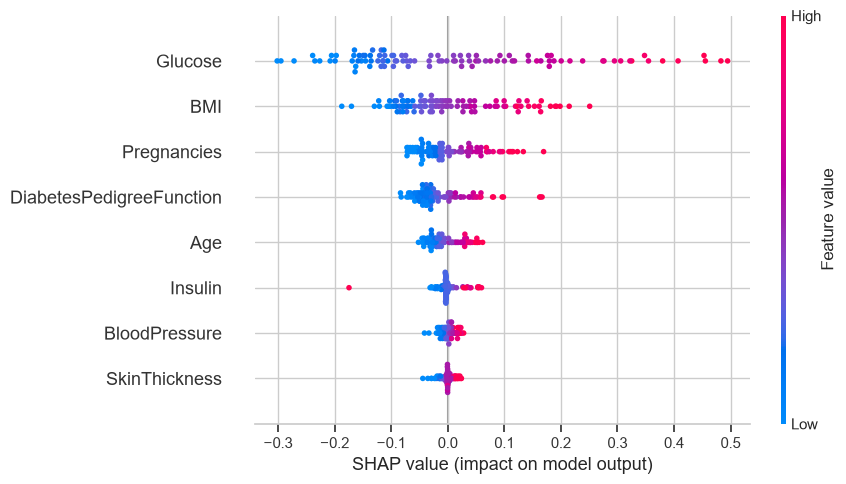

In [24]:
shap.summary_plot(shap_values, frame, show=False, plot_size=(9, 5))
plt.show()

C:\Users\mmahmoud\AppData\Local\Temp\ipykernel_47184\4226519121.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, frame, plot_type='bar', show=False, plot_size=(9, 4.5))


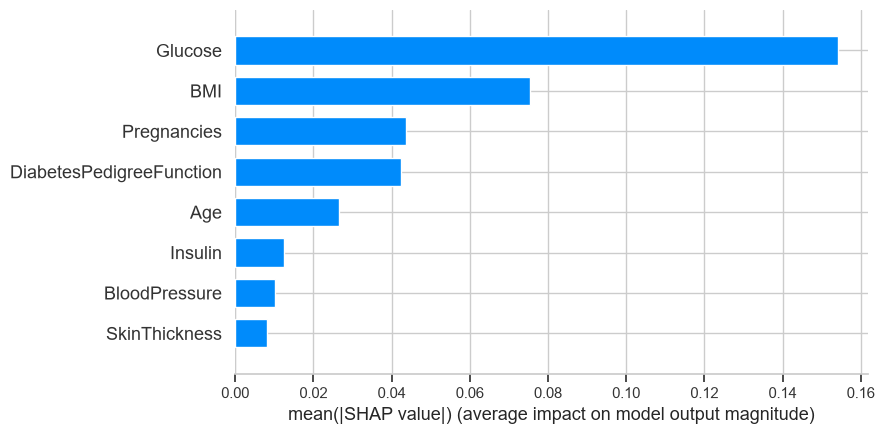

Glucose                     0.1541
BMI                         0.0753
Pregnancies                 0.0438
DiabetesPedigreeFunction    0.0424
Age                         0.0265
Insulin                     0.0125
BloodPressure               0.0101
SkinThickness               0.0081
dtype: float64

In [25]:
shap.summary_plot(shap_values, frame, plot_type='bar', show=False, plot_size=(9, 4.5))
plt.show()

pd.Series(np.abs(shap_values).mean(axis=0),
          index=FEATURES).sort_values(ascending=False).round(4)

The beeswarm plot reads as follows: each dot is one patient, its horizontal position is how much that
feature pushed the prediction towards diabetes, and its colour is whether the feature value was high
(red) or low (blue).

**High glucose (red dots on the right of the top row) pushes the prediction towards diabetes, low
glucose pulls it back** - the model has learned the clinically correct direction, not an artefact.
The same holds for BMI. This directional sanity check is the point of running SHAP at all: a model
with the right accuracy but an inverted relationship would be dangerous, and this plot would expose it.

## 9. Saving the model

In [26]:
Path('models').mkdir(exist_ok=True)
joblib.dump({'pipeline': best_pipe, 'threshold': threshold,
             'features': FEATURES, 'model_name': best_name},
            'models/best_model.joblib')

# Reload and verify the saved artefact reproduces the same predictions.
loaded = joblib.load('models/best_model.joblib')
reloaded_pred = (loaded['pipeline'].predict_proba(X_test)[:, 1] >= loaded['threshold']).astype(int)
print('saved model reproduces predictions:', bool((reloaded_pred == pred_tuned).all()))
print('bundled threshold:', loaded['threshold'])

saved model reproduces predictions: True
bundled threshold: 0.285


In [27]:
# Final summary, printed from the computed variables so it cannot drift from the results above.
cm_d, cm_t = confusion_matrix(y_test, pred_default), confusion_matrix(y_test, pred_tuned)
print(f'Best model            : {best_name}  {best_row["best_params"]}')
print(f'CV ROC-AUC (train)    : {best_row["cv_roc_auc"]:.4f}')
print(f'Test ROC-AUC          : {best_row["test_roc_auc"]:.4f}')
print()
print(f'At threshold 0.50     : accuracy {scores(pred_default)["accuracy"]:.4f}   '
      f'recall {scores(pred_default)["recall"]:.4f}   precision {scores(pred_default)["precision"]:.4f}   '
      f'missed diabetics {cm_d[1, 0]}/{cm_d[1].sum()}')
print(f'At threshold {threshold:.2f}     : accuracy {scores(pred_tuned)["accuracy"]:.4f}   '
      f'recall {scores(pred_tuned)["recall"]:.4f}   precision {scores(pred_tuned)["precision"]:.4f}   '
      f'missed diabetics {cm_t[1, 0]}/{cm_t[1].sum()}')
print()
print(f'Majority-class baseline accuracy: {1 - y_test.mean():.4f} (catches 0 diabetics)')

Best model            : SVM (RBF)  {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01}
CV ROC-AUC (train)    : 0.8493
Test ROC-AUC          : 0.8096

At threshold 0.50     : accuracy 0.7078   recall 0.5000   precision 0.6000   missed diabetics 27/54
At threshold 0.28     : accuracy 0.7208   recall 0.8148   precision 0.5714   missed diabetics 10/54

Majority-class baseline accuracy: 0.6494 (catches 0 diabetics)


## 10. Discussion and conclusion

### What was built

A screening classifier for type 2 diabetes from eight routine measurements. Five algorithms were
compared under identical preprocessing; the winner was selected on cross-validated ROC-AUC computed
on the training set alone, tuned by grid search, and given a decision threshold chosen from
out-of-fold predictions to hit a recall target. The test set was used exactly once, at the end.

### Results

The tuned **SVM with an RBF kernel** was selected (CV ROC-AUC **0.849**, test ROC-AUC **0.810**).
Logistic Regression was within a hair of it (CV ROC-AUC 0.845), which says something worth saying:
on 614 training rows with eight features, a well-regularised linear model is competitive with
anything more elaborate. The single Decision Tree was the clear loser (CV ROC-AUC 0.651).

The threshold is where the interesting result is:

| | Accuracy | Precision | Recall | Missed diabetics |
|---|---|---|---|---|
| Default threshold 0.50 | 0.708 | 0.600 | 0.500 | **27 of 54** |
| Chosen threshold 0.285 | 0.721 | 0.571 | **0.815** | **10 of 54** |

Moving the threshold converts a model that misses more than half of all diabetics into one that
catches four in five. The cost is precision falling from 0.60 to 0.57 - that is, more healthy
patients sent for a confirmatory test. For a screening tool that is an unambiguously good trade, and
it is invisible if you only ever look at `predict()` and accuracy.

Note also that accuracy barely moved (0.708 → 0.721) while recall gained 31 points. Accuracy was
simply not measuring the thing we care about.

### What drives the predictions

Permutation importance and SHAP agree on the ordering: **Glucose** dominates, then **BMI**, then
**Pregnancies** and **DiabetesPedigreeFunction**. SHAP confirms the directions are clinically
correct - high glucose and high BMI push towards a diabetes prediction. `SkinThickness` and
`BloodPressure` contribute almost nothing, exactly as the EDA distributions suggested.

That glucose leads is reassuring rather than surprising: plasma glucose is part of how diabetes is
diagnosed. It does mean the model is partly re-deriving a known definition, which limits how much
genuinely new information it adds over a glucose test alone.

### Limitations

1. **Small and narrow.** 768 patients, all women of Pima heritage aged 21+ near Phoenix. Nothing here
   licenses use on men, on other ethnic groups, or on younger patients. The Pima population has an
   unusually high diabetes prevalence, so the base rate itself does not transfer.
2. **Heavy imputation.** Roughly half the insulin values and a third of the skin-fold values were
   absent and filled with the median. Those two features are consequently the least trustworthy in
   the model - and, tellingly, they rank near the bottom of the importance plots.
3. **Missingness is probably not random.** A patient with no recorded insulin value likely differs
   systematically from one who has it. Median imputation assumes otherwise.
4. **No external validation.** All results come from one 154-patient test split of a single dataset.
   The confidence interval on a recall of 0.815 measured on 54 positives is wide.
5. **Ceiling.** ROC-AUC near 0.81-0.85 is in line with published results on this dataset. Eight
   coarse measurements only carry so much signal; better results need better features (HbA1c, fasting
   glucose, waist circumference), not fancier models.

### Conclusion

The workflow succeeds at what it set out to do. The decisive gains came from **preprocessing**
(recognising that the zeros were missing values) and from **choosing an operating threshold that
matches the clinical cost of each error** - not from the choice of algorithm, where four of the five
models landed within a few points of each other. As a triage aid that flags roughly 80% of diabetics
for confirmatory testing, the model is plausible. As a diagnostic device, it is not, and the
limitations above are the reasons.

### Future work

External validation on a broader cohort; multiple imputation instead of median filling, with a
missing-indicator feature; calibration curves so the predicted probabilities can be read as real
risks; and cost-sensitive learning driven by the actual monetary and clinical cost of each error type.

---

## References

1. Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., Johannes, R.S. (1988). *Using the ADAP
   learning algorithm to forecast the onset of diabetes mellitus.* Proceedings of the Symposium on
   Computer Applications in Medical Care, 261-265.
2. Dua, D. and Graff, C. (2019). *UCI Machine Learning Repository - Pima Indians Diabetes Database.*
   University of California, Irvine.
3. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825-2830.
4. Lundberg, S.M. and Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions.*
   Advances in Neural Information Processing Systems 30.
5. Saito, T. and Rehmsmeier, M. (2015). *The Precision-Recall Plot Is More Informative than the ROC
   Plot When Evaluating Binary Classifiers on Imbalanced Datasets.* PLOS ONE 10(3).